In [1]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from itertools import combinations
import seaborn as sns
from statsmodels.stats.multitest import multipletests



dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07","EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
  "PETDWS2B": "2024-08-01",   "PETDWS2C": "2024-08-01",   "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07", "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}

alles=[]
MT=[]

med=[]
for f in glob.glob("*.report.txt"):
    if "NE.AACMFLCHV" not in f and "NTC" not in f:
        df=pd.read_csv(f,sep="\t", skiprows=2)
        df["sample"]=re.sub(".AACMFLCHV.1.cleaned_bbdukclean.report.txt", "", f)
        df['taxName'] = df['taxName'].str.strip()
        alles.append(df)
        med.append(df[0:2]["reads"].sum())
        bacteria_idx = df.index[df['taxName'] == 'Viruses']
    
        if len(bacteria_idx) == 0:
            subset = pd.DataFrame() 
        else:
            start_idx = bacteria_idx[0]
            end_idx = df.index[-1] 
            bactsubset = df.loc[start_idx:end_idx]
            MT.append(bactsubset)
        
        
MTori=pd.concat(MT)
alles=pd.concat(alles)
MT=MTori[(MTori["reads"]>=10) & (MTori["kmers"]>=660)]MT["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in MT["sample"]]
MT["dates"]=MT["sample"].str.replace("_", "").map(dates)


tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
rr=dict(zip(tdf["sample"], tdf["num_seqs"]))
MT["total_reads"]=MT["sample"].map(rr)
MT=MT[MT["rank"]=="family"]
MT=MT.rename(columns={"taxName":"family", "reads": "read_count"})

In [2]:
rpm_df = MT.dropna(subset=["canal", "family"]).groupby(["canal", "family"], as_index=False).agg(read_count=("read_count", "sum"),total_reads=("total_reads", "sum"))
rpm_df["RPM"] = rpm_df["read_count"] / rpm_df["total_reads"] * 1000000

,canal,family,read_count,total_reads,RPM
0,AJA,Ackermannviridae,136,40346057,3.370837
1,AJA,Adenoviridae,3158,54964990,57.454754
2,AJA,Astroviridae,6302,54964990,114.654801
3,AJA,Autographiviridae,1858,47573802,39.055109
4,AJA,Caliciviridae,321,14618933,21.957827
...,...,...,...,...,...
84,PET,Polyomaviridae,46,10058632,4.573186
85,PET,Schitoviridae,636,27258467,23.332200
86,PET,Siphoviridae,4371,32621074,133.993136
87,PET,Steigviridae,224,16981523,13.190807


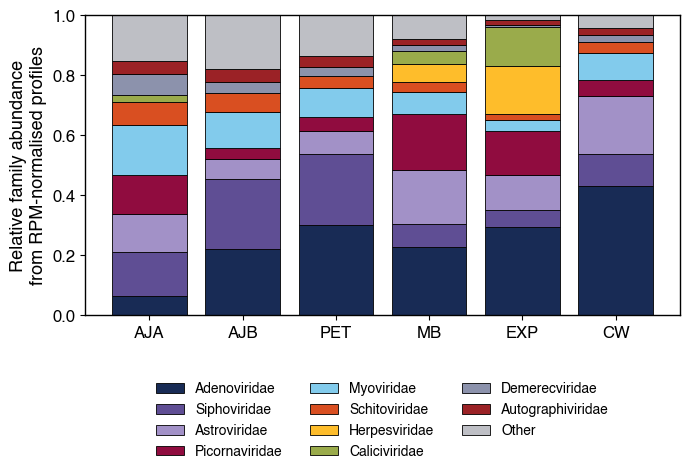

In [4]:
cols = ['#182b55', '#5f4e94', '#a291c7', '#900c3f', '#82cbec', '#d94f21','#febd2b', '#9aab4b', "#8C92AC", "#9b2226", "#6a4c93", "#1982c4","#8ac926", "#ff595e", "#FFFDD0", "#ffca3a", "#8338ec", "#3a86ff"]


plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)
plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)
cf = plot_df.groupby(["canal", "family"], as_index=False)["RPM"].sum()

top_f = cf.groupby("family")["RPM"].sum().sort_values(ascending=False).head(10).index.tolist()

cf["family_collapsed"] = np.where(cf["family"].isin(top_f),cf["family"],"Other")
cfc = cf.groupby(["canal", "family_collapsed"], as_index=False)["RPM"].sum().rename(columns={"family_collapsed": "family"})

crpm = cfc.pivot(index="canal", columns="family", values="RPM").fillna(0)
c_rel = crpm.div(crpm.sum(axis=1), axis=0).fillna(0)

co = ["AJA", "AJB", "PET", "MB", "EXP", "CW"]
co = [c for c in co if c in c_rel.index]
c_rel = c_rel.loc[co]
f_o = c_rel.drop(columns=["Other"], errors="ignore").sum(axis=0).sort_values(ascending=False).index.tolist()


if "Other" in c_rel.columns:
    f_o = f_o + ["Other"]

c_rel = c_rel[f_o]

c_m = {fam: cols[i % len(cols)]  for i, fam in enumerate([f for f in f_o if f != "Other"])}
c_m["Other"] = "#BEBFC5"

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(c_rel))

for fam in f_o:
    vals = c_rel[fam].values
    ax.bar(c_rel.index, vals, bottom=bottom, label=fam, color=c_m[fam], edgecolor="black", linewidth=0.6)
    bottom += vals

ax.set_xlabel("")
ax.set_ylabel("Relative family abundance\nfrom RPM-normalised profiles", fontsize=13)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=10)

ax.grid(False)

plt.tight_layout()
plt.show()

In [5]:
lot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)

plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)


cf_rpm_sum = plot_df.groupby(["canal", "family"], as_index=False)["RPM"].sum()
c_rpm = cf_rpm_sum.pivot(index="canal", columns="family", values="RPM").fillna(0)

c_rel = c_rpm.div(c_rpm.sum(axis=1),axis=0).fillna(0)
c_rel = c_rel.loc[co]
families = c_rel.sum(axis=0).sort_values(ascending=False).index.tolist()
c_rel = c_rel[families]

family,Adenoviridae,Siphoviridae,Astroviridae,Picornaviridae,Myoviridae,Schitoviridae,Herpesviridae,Caliciviridae,Demerecviridae,Autographiviridae,Podoviridae,Virgaviridae,Steigviridae,Casjensviridae,Ackermannviridae,Polyomaviridae,Drexlerviridae,Herelleviridae,Chaseviridae,Solemoviridae
canal,,,,,,,,,,,,,,,,,,,,
AJA,0.064372,0.145153,0.128459,0.128372,0.168882,0.074891,0.000000,0.024602,0.068839,0.043757,0.034240,0.047690,0.018661,0.008053,0.003777,0.005760,0.010747,0.017217,0.003888,0.002638
AJB,0.219942,0.234984,0.064394,0.038473,0.118222,0.063886,0.000000,0.000000,0.038134,0.042269,0.040327,0.033755,0.043526,0.028142,0.024765,0.000000,0.009181,0.000000,0.000000,0.000000
PET,0.301483,0.235866,0.075362,0.046689,0.098318,0.041071,0.000000,0.000000,0.029543,0.034484,0.034072,0.019761,0.023220,0.026953,0.000000,0.008050,0.005805,0.019324,0.000000,0.000000
MB,0.228451,0.076802,0.177261,0.188797,0.072537,0.033914,0.059709,0.042504,0.020096,0.022261,0.011414,0.010497,0.014538,0.007932,0.017665,0.009376,0.006249,0.000000,0.000000,0.000000
EXP,0.293412,0.057619,0.117981,0.146504,0.035753,0.018783,0.159627,0.132771,0.005556,0.015410,0.010556,0.001397,0.000000,0.000000,0.000000,0.000000,0.004630,0.000000,0.000000,0.000000
CW,0.430011,0.105939,0.194470,0.055458,0.086862,0.038510,0.000000,0.000000,0.023354,0.022401,0.000000,0.008444,0.013935,0.000000,0.000000,0.020617,0.000000,0.000000,0.000000,0.000000


In [6]:
bc_m = pd.DataFrame(squareform(pdist(c_rel.values, metric="braycurtis")),index=c_rel.index,columns=c_rel.index)

bc_m

canal,AJA,AJB,PET,MB,EXP,CW
canal,,,,,,
AJA,0.000000,0.317430,0.355677,0.368419,0.514968,0.446506
AJB,0.317430,0.000000,0.128982,0.383288,0.527487,0.377747
PET,0.355677,0.128982,0.000000,0.365653,0.434832,0.268971
MB,0.368419,0.383288,0.365653,0.000000,0.255147,0.281466
EXP,0.514968,0.527487,0.434832,0.255147,0.000000,0.398631
CW,0.446506,0.377747,0.268971,0.281466,0.398631,0.000000


In [8]:
distances = { ("AJB", "PET"): 0.44, ("AJB", "MB"): 1.65, ("AJB", "EXP"): 1.75,("AJB", "CW"): 2.70,("AJB", "AJA"): 1, ("PET", "MB"): 1.25, ("PET", "EXP"): 1.30, 
              ("PET", "CW"): 2.27, ("PET", "AJA"): 0.6,("AJA", "MB"): 1.20, ("AJA", "EXP"): 1.30,("AJA", "CW"): 2.25, ("MB", "EXP"): 0.10,("MB", "CW"): 1.10,("EXP", "CW"): 1.00,}



bcm = pd.DataFrame(squareform(pdist(c_rel.values, metric="braycurtis")), index=c_rel.index, columns=c_rel.index)

decay_r = []
for (c1, c2), dist in distances.items():
    if c1 in bcm.index and c2 in bc_matrix.columns:
        bc = bcm.loc[c1, c2]
        decay_r.append({"canal_1": c1, "canal_2": c2, "pair": f"{c1}-{c2}", "distance_km": dist, "bray_curtis": bc, "similarity": 1 - bc})

decay_df = pd.DataFrame(decadecay_ry_rows)
decay_df = decay_df.sort_values("distance_km")
decay_df



,canal_1,canal_2,pair,distance_km,bray_curtis,similarity
10,MB,EXP,MB-EXP,0.10,0.255147,0.744853
0,AJB,PET,AJB-PET,0.44,0.128982,0.871018
12,EXP,CW,EXP-CW,1.00,0.398631,0.601369
11,MB,CW,MB-CW,1.10,0.281466,0.718534
7,AJA,MB,AJA-MB,1.20,0.368419,0.631581
4,PET,MB,PET-MB,1.25,0.365653,0.634347
5,PET,EXP,PET-EXP,1.30,0.434832,0.565168
8,AJA,EXP,AJA-EXP,1.30,0.514968,0.485032
1,AJB,MB,AJB-MB,1.65,0.383288,0.616712
2,AJB,EXP,AJB-EXP,1.75,0.527487,0.472513


In [ ]:
rho, pval = spearmanr(decay_df["distance_km"],decay_df["bray_curtis"])

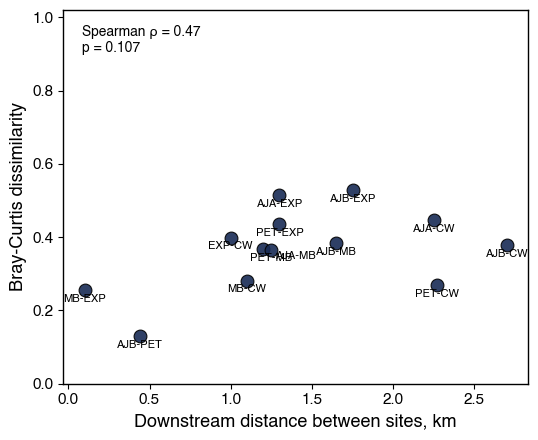

In [10]:
loffs = {"AJB-PET": (0.00, -0.01), "AJB-MB":  (0.00, -0.01), "AJB-EXP": (0.00, -0.01), "AJB-CW":  (0.00, -0.01), "PET-MB":  (0.00, -0.01), "PET-EXP": (0.00, -0.01), "PET-CW":  (0.00, -0.01), "AJA-MB":  (0.2, -0.005), "AJA-EXP": (0.00, -0.01), "AJA-CW":  (0.00, -0.01), "MB-EXP":  (0.00, -0.01), "MB-CW":   (0.00, -0.01),  "EXP-CW":  (0.00, -0.01),}

fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(data=decay_df, x="distance_km", y="bray_curtis", s=85, edgecolor="black", linewidth=0.8, alpha=0.9, color="#182b55", ax=ax)

for _, row in decay_df.iterrows():
    dx, dy = loffs.get(row["pair"], (0.00, -0.005))
    ax.text(row["distance_km"] + dx, row["bray_curtis"] + dy, row["pair"], fontsize=8, ha="center", va="top", color="black")

ax.text(0.04, 0.96, f"Spearman ρ = {rho:.2f}\np = {pval:.3g}", transform=ax.transAxes, ha="left", va="top",fontsize=10)

ax.set_xlabel("Downstream distance between sites, km", fontsize=13)
ax.set_ylabel("Bray-Curtis dissimilarity", fontsize=13)

ax.tick_params(axis="x", labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
ax.set_ylim(0,1)

ymin, ymax = ax.get_ylim()
ax.set_ylim(max(0, ymin - 0.05), ymax + 0.02)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)
plt.tight_layout()

plt.show()

In [11]:
rpm_df = MT.dropna(subset=["canal", "dates", "family"]).groupby(["canal","dates", "family"], as_index=False).agg(read_count=("read_count", "sum"),total_reads=("total_reads", "sum"))
rpm_df["RPM"] = rpm_df["read_count"] / rpm_df["total_reads"] * 1000000
rpm_df

,canal,dates,family,read_count,total_reads,RPM
0,AJA,2024-07-25,Ackermannviridae,136,40346057,3.370837
1,AJA,2024-07-25,Adenoviridae,63,40346057,1.561491
2,AJA,2024-07-25,Astroviridae,382,40346057,9.468088
3,AJA,2024-07-25,Autographiviridae,1736,40346057,43.027749
4,AJA,2024-07-25,Casjensviridae,290,40346057,7.187815
...,...,...,...,...,...,...
187,PET,2024-08-07,Podoviridae,134,6922891,19.356075
188,PET,2024-08-07,Schitoviridae,473,6922891,68.324057
189,PET,2024-08-07,Siphoviridae,2936,6922891,424.100278
190,PET,2024-08-07,Steigviridae,103,6922891,14.878177


In [13]:
df = rpm_df.copy()
df["dates"] = pd.to_datetime(df["dates"])
df["RPM"] = pd.to_numeric(df["RPM"], errors="coerce").fillna(0)

df = df.groupby(["canal", "dates", "family"], as_index=False)["RPM"].sum()


def bray_curtis_family_contributions(group, date_value):
    wide = group.pivot_table(index="canal", columns="family", values="RPM", fill_value=0, aggfunc="sum")
    rr = []
    for c1, c2 in combinations(wide.index, 2):
        x = wide.loc[c1]
        y = wide.loc[c2]
        
        abs_diff = (x - y).abs()
        abundance_sum = x + y
        numerator = abs_diff.sum()
        denominator = abundance_sum.sum()
        bray_curtis = numerator / denominator if denominator > 0 else np.nan
        for family in wide.columns:
            family_abs_diff = abs_diff[family]
            c_to_diff = (family_abs_diff / numerator * 100 if numerator > 0 else np.nan)
            c_bc = (family_abs_diff / denominator * 100  if denominator > 0 else np.nan )
            rr.append({ "dates": date_value, "canal_1": c1, "canal_2": c2, "family": family, "RPM_1": x[family],"RPM_2": y[family], "abs_difference": family_abs_diff, "bray_curtis": bray_curtis, "percent_contribution_to_difference": c_to_diff, "percent_contribution_to_bray_curtis": c_bc })
    
    return pd.DataFrame(rr)



out = []
for date_value, group in df.groupby("dates"):
    tmp = bray_curtis_family_contributions(group, date_value)
    out.append(tmp)
family_contrib = pd.concat(out, ignore_index=True)


high_bc = family_contrib[family_contrib["bray_curtis"] >= 0.5].copy()
# high_bc["dates"] = pd.to_datetime(high_bc["dates"]).dt.strftime("%Y-%m-%d")
high_bc_pair= high_bc[["dates", "canal_1", "canal_2", "bray_curtis"]].drop_duplicates().sort_values(["dates", "bray_curtis"], ascending=[True, False])

high_bc_family_summary = high_bc.groupby("family", as_index=False).agg(n_high_bc_pairs=("percent_contribution_to_difference", "count"), mean_percent_contribution=("percent_contribution_to_difference", "mean"), median_percent_contribution=("percent_contribution_to_difference", "median"), max_percent_contribution=("percent_contribution_to_difference", "max"), mean_abs_difference=("abs_difference", "mean"), median_abs_difference=("abs_difference", "median")).sort_values("mean_percent_contribution", ascending=False)
high_bc_family_summary.head(15)

,family,n_high_bc_pairs,mean_percent_contribution,median_percent_contribution,max_percent_contribution,mean_abs_difference,median_abs_difference
2,Astroviridae,27,22.988359,20.875245,54.883090,298.057562,298.768020
1,Adenoviridae,27,22.811944,22.285553,43.803123,329.475870,257.254788
12,Picornaviridae,27,13.661840,10.918179,32.566844,230.894409,86.698683
16,Siphoviridae,27,12.395961,5.899580,52.726044,184.005978,57.577933
11,Myoviridae,27,8.264522,6.193864,20.364420,101.730913,58.114903
15,Schitoviridae,27,3.327696,2.491328,10.174599,37.852118,34.332534
4,Caliciviridae,27,3.158018,3.010044,7.210222,55.381333,27.272607
10,Herpesviridae,19,2.923084,0.000000,9.688436,62.637989,0.000000
7,Demerecviridae,27,2.643258,1.879511,9.770681,30.419879,20.392886
3,Autographiviridae,27,2.228845,1.724063,5.997658,25.092468,21.995549


In [14]:
top3_high_bc = high_bc.sort_values(["dates", "canal_1", "canal_2", "percent_contribution_to_difference"],ascending=[True, True, True, False]).groupby(["dates", "canal_1", "canal_2"]).head(3)
top_d = top3_high_bc.groupby("family", as_index=False).agg(times_in_top3=("family", "count"), mean_top3_contribution=("percent_contribution_to_difference", "mean"), median_top3_contribution=("percent_contribution_to_difference", "median"), max_top3_contribution=("percent_contribution_to_difference", "max")).sort_values(["times_in_top3", "mean_top3_contribution"], ascending=[False, False])

top_d

,family,times_in_top3,mean_top3_contribution,median_top3_contribution,max_top3_contribution
0,Adenoviridae,22,26.706721,25.848624,43.803123
1,Astroviridae,19,30.274461,27.132815,54.883090
4,Picornaviridae,16,20.080215,18.749833,32.566844
6,Siphoviridae,10,27.569577,20.060312,52.726044
3,Myoviridae,9,15.580458,15.408727,20.364420
5,Schitoviridae,3,7.323299,5.967941,10.174599
2,Herpesviridae,2,9.106170,9.106170,9.688436


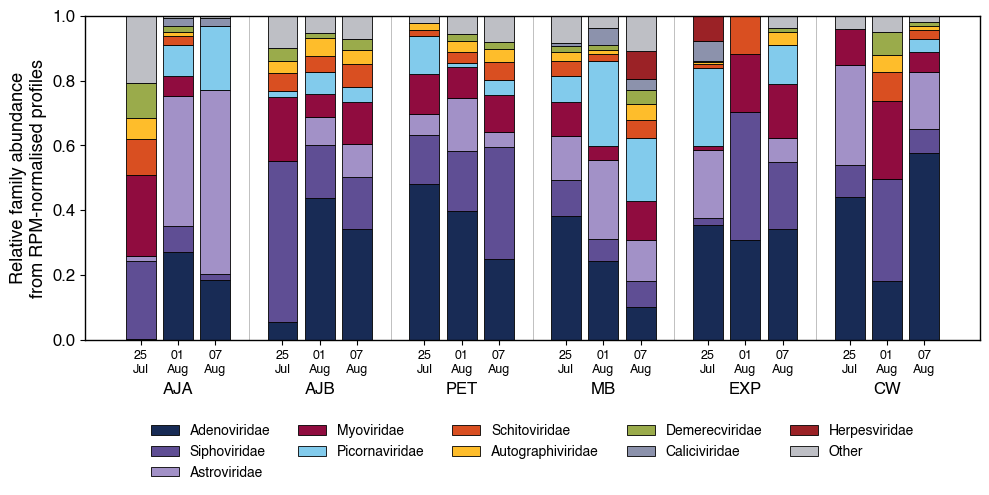

In [16]:
plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)
plot_df["family"] = plot_df["family"].astype(str).str.replace("f__", "", regex=False)
plot_df["dates"] = pd.to_datetime(plot_df["dates"])
plot_df["date_label"] = plot_df["dates"].dt.strftime("%Y-%m-%d")
cdf = plot_df.groupby(["canal", "date_label", "family"], as_index=False)["RPM"].sum()


top_f = cdf.groupby("family")["RPM"].sum().sort_values(ascending=False).head(10).index.tolist()
cdf["family_collapsed"] = np.where(cdf["family"].isin(top_f),cdf["family"], "Other")
cdf = cdf.groupby(["canal", "date_label", "family_collapsed"], as_index=False)["RPM"].sum().rename(columns={"family_collapsed": "family"})

canal_date_rpm = cdf.pivot_table(index=["canal", "date_label"], columns="family", values="RPM", fill_value=0)

canal_date_rel = canal_date_rpm.div(canal_date_rpm.sum(axis=1),axis=0).fillna(0)
do = sorted(canal_date_rel.index.get_level_values("date_label").unique())

ordered_index = pd.MultiIndex.from_product([canal_order, do],names=["canal", "date_label"])
canal_date_rel = canal_date_rel.reindex(ordered_index).fillna(0)

f_o = canal_date_rel.drop(columns=["Other"], errors="ignore").sum(axis=0).sort_values(ascending=False).index.tolist()

if "Other" in canal_date_rel.columns:
    f_o = f_o + ["Other"]
canal_date_rel = canal_date_rel[f_o]

c_m = {fam: cols[i % len(cols)] for i, fam in enumerate([f for f in f_o if f != "Other"])}
c_m["Other"] = "#BEBFC5"



bar_width = 0.8
gap = 0.8
x_positions = []
x_date_labels = []
canal_centers = []

x = 0
for canal in canal_order:
    group_x = []
    for date in date_order:
        x_positions.append(x)
        x_date_labels.append(date)
        group_x.append(x)
        x += 1
    canal_centers.append(np.mean(group_x))
    x += gap

x_positions = np.array(x_positions)

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(canal_date_rel))

for fam in f_o:
    vals = canal_date_rel[fam].values
    ax.bar(x_positions, vals, bottom=bottom, width=bar_width, label=fam, color=c_m[fam], edgecolor="black",linewidth=0.6)
    bottom += vals

ax.set_xticks(x_positions)
ax.set_xticklabels([pd.to_datetime(d).strftime("%d\n%b") for d in x_date_labels], fontsize=9)

for center, canal in zip(canal_centers, canal_order):
    ax.text(center, -0.13, canal, ha="center", va="top", fontsize=12, fontweight="bold", transform=ax.get_xaxis_transform())

for i in range(1, len(canal_order)):
    sep = (canal_centers[i - 1] + canal_centers[i]) / 2
    ax.axvline(sep, color="black", linewidth=0.7, alpha=0.25)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance in RPM profiles", fontsize=13)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=9, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend(title="",loc="upper center", bbox_to_anchor=(0.5, -0.22),ncol=6,frameon=False, fontsize=10)

ax.grid(False)

ax.set_xlim(x_positions.min() - bar_width / 2, x_positions.max() + bar_width / 2)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()


plt.show()

In [13]:
canal_date_rel.head()

family            Ackermannviridae  Adenoviridae  Astroviridae  \
canal date_label                                                 
AJA   2024-07-25          0.005138      0.002380      0.014432   
      2024-08-01          0.000000      0.269939      0.403304   
      2024-08-07          0.000000      0.184629      0.566211   
AJB   2024-07-25          0.011591      0.055585      0.000000   
      2024-08-01          0.000000      0.437191      0.087732   

family            Autographiviridae  Caliciviridae  Casjensviridae  \
canal date_label                                                     
AJA   2024-07-25           0.065586       0.000000        0.010956   
      2024-08-01           0.014501       0.025318        0.000000   
      2024-08-07           0.000000       0.024199        0.000000   
AJB   2024-07-25           0.037759       0.000000        0.013172   
      2024-08-01           0.056293       0.000000        0.000000   

family            Chaseviridae  Demerecviridae  Drexlerviridae  \
canal date_label                                                 
AJA   2024-07-25      0.005289        0.105406        0.014621   
      2024-08-01      0.000000        0.015809        0.000000   
      2024-08-07      0.000000        0.000000        0.000000   
AJB   2024-07-25      0.000000        0.041096        0.009747   
      2024-08-01      0.000000        0.015684        0.009820   

family            Herelleviridae  Herpesviridae  Myoviridae  Picornaviridae  \
canal date_label                                                              
AJA   2024-07-25        0.023424            0.0    0.251464        0.000000   
      2024-08-01        0.000000            0.0    0.061215        0.094259   
      2024-08-07        0.000000            0.0    0.000000        0.197625   
AJB   2024-07-25        0.000000            0.0    0.199420        0.016596   
      2024-08-01        0.000000            0.0    0.071604        0.067290   

family            Podoviridae  Polyomaviridae  Schitoviridae  Siphoviridae  \
canal date_label                                                             
AJA   2024-07-25     0.046583        0.000000       0.111262      0.240394   
      2024-08-01     0.000000        0.000000       0.027933      0.080114   
      2024-08-07     0.000000        0.008514       0.000000      0.018821   
AJB   2024-07-25     0.025904        0.000000       0.056112      0.494643   
      2024-08-01     0.000000        0.000000       0.049257      0.163049   

family            Solemoviridae  Steigviridae  Virgaviridae  
canal date_label                                             
AJA   2024-07-25       0.003589      0.025388      0.074087  
      2024-08-01       0.000000      0.000000      0.007607  
      2024-08-07       0.000000      0.000000      0.000000  
AJB   2024-07-25       0.000000      0.020372      0.018001  
      2024-08-01       0.000000      0.000000      0.042080

In [21]:
canal_date_rel = canal_date_rpm.div(canal_date_rpm.sum(axis=1),axis=0).fillna(0)
dr = []

for date in do:
    sub = canal_date_rel.xs(date, level="date_label")
    if sub.shape[0] < 2:
        continue

    bcm = pd.DataFrame(squareform(pdist(sub.values, metric="braycurtis")), index=sub.index, columns=sub.index)
    for (c1, c2), dist in distances.items():
        if c1 in bcm.index and c2 in bcm.columns:
            bc = bcm.loc[c1, c2]
            dr.append({"date": date, "canal_1": c1, "canal_2": c2, "pair": f"{c1}-{c2}", "distance_km": dist, "bray_curtis": bc, "similarity": 1 - bc})

dt_df = pd.DataFrame(dr)

dt_df.head()

,date,canal_1,canal_2,pair,distance_km,bray_curtis,similarity
0,2024-07-25,AJB,PET,AJB-PET,0.44,0.591597,0.408403
1,2024-07-25,AJB,MB,AJB-MB,1.65,0.567940,0.432060
2,2024-07-25,AJB,EXP,AJB-EXP,1.75,0.872399,0.127601
3,2024-07-25,AJB,CW,AJB-CW,2.70,0.713423,0.286577
4,2024-07-25,PET,MB,PET-MB,1.25,0.198962,0.801038


In [22]:
ddr2 = []
for date, sub in dt_df.groupby("date"):
    rho, pval = spearmanr(sub["distance_km"], sub["bray_curtis"])
    ddr2.append({"date": date, "n_pairs": len(sub),"spearman_rho": rho, "p_value": pval})

ddr2 = pd.DataFrame(ddr2)

ddr2

,date,n_pairs,spearman_rho,p_value
0,2024-07-25,13,0.382394,0.197222
1,2024-08-01,13,0.203577,0.504716
2,2024-08-07,13,0.038514,0.900588


In [23]:
ddr2["p_adj_BH"] = multipletests(ddr2["p_value"],method="fdr_bh")[1]

ddr2

,date,n_pairs,spearman_rho,p_value,p_adj_BH
0,2024-07-25,13,0.382394,0.197222,0.591666
1,2024-08-01,13,0.203577,0.504716,0.757074
2,2024-08-07,13,0.038514,0.900588,0.900588


In [ ]:
rho_all, p_all = spearmanr(decay_tidt_dfme_df["distance_km"], dt_df["bray_curtis"])


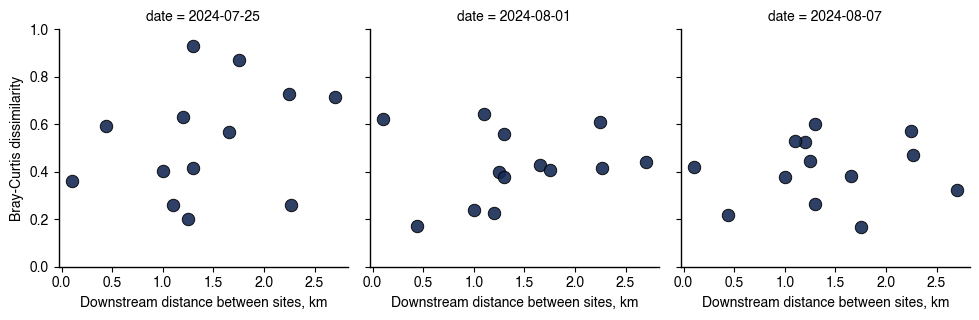

In [25]:
g = sns.lmplot(data=decay_time_df,x="distance_km", y="bray_curtis", col="date", col_wrap=3, height=3.3, aspect=1,fit_reg=False, scatter_kws={ "s": 80, "edgecolor": "black", "linewidths": 0.7,"alpha": 0.9, "color": "#182b55"})
g.set_axis_labels("Downstream distance between sites, km", "Bray-Curtis dissimilarity")

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()